# Grandmeister Station:
Datsets worked with:
1. Grandmeister Transfer Transactions Dataset merged with sand ocean weather dataset.

# Problem Statement:

“Predict average flow rates and analyze fuel dispensing patterns at Grandmeister units to optimize equipment usage and reduce downtime.”

# Data Cleaning

In [121]:
import pandas as pd

df = pd.read_csv("/content/Cleaned_Transfer_Transations_merged.csv")
df.head()

,Date,End Time,Duration in Seconds,Transfer From,Source ID,Transfer To,Target ID,Product,Volume,Metered Volume,...,realtime_source,wind_direction_deg,dewpoint_temp_c,air_temp_c,humidity_percent,precipitation_mm,utc_date,Wind Direction Category,Feels Like Temp,Rain Intensity
0,19-11-2024 12:44,19-11-2024 12:50,333,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,TLP 2104,TLP 2104,DIESEL,1864.7,1864.7,...,False,360,-11.2,-8.6,81,0.0,19-11-2024 12:00,N,-12.4,NaN
1,19-11-2024 15:24,19-11-2024 15:26,103,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,373.9,373.9,...,False,360,-11.8,-10.0,87,0.0,19-11-2024 15:00,N,-12.6,NaN
2,19-11-2024 16:40,19-11-2024 16:58,1083,Mod 4 Lube Island Virtual,K4 Lube Island Virtual,Grandmeister Unit 9042 Diesel,Grandmeister Unit 9042 Diesel,DIESEL,6306.1,6306.1,...,True,356,-13.3,-11.1,84,0.0,19-11-2024 16:00,N,-14.3,NaN
3,19-11-2024 16:42,19-11-2024 16:52,631,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9423 Diesel,Grandmeister Unit 9423 Diesel,DIESEL,3121.3,3121.3,...,True,356,-13.3,-11.1,84,0.0,19-11-2024 16:00,N,-14.3,NaN
4,19-11-2024 16:46,19-11-2024 17:02,961,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,5108.8,5108.8,...,True,356,-13.3,-11.1,84,0.0,19-11-2024 16:00,N,-14.3,NaN


In [122]:
import pandas as pd
df['Rain Intensity'].unique()
# Check the mode of the 'Rain Intensity' column
mode_value = df['Rain Intensity'].mode()[0]

# Impute missing values with the mode value
df['Rain Intensity'].fillna(mode_value, inplace=True)

<ipython-input-122-b49031a4513b>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rain Intensity'].fillna(mode_value, inplace=True)


In [123]:
# Convert date columns to datetime
df['Date'] = pd.to_datetime(df['Date'])
df['End Time'] = pd.to_datetime(df['End Time'])
df['Start Time'] = pd.to_datetime(df['Start Time'])
df['utc_date'] = pd.to_datetime(df['utc_date'])

# Convert Flow Duration to timedelta if it's in time format
df['Flow Duration'] = pd.to_timedelta(df['Flow Duration'])

# Convert Rain Intensity to a categorical type for better performance
df['Rain Intensity'] = pd.Categorical(df['Rain Intensity'])

<ipython-input-123-8614359cd07c>:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])
<ipython-input-123-8614359cd07c>:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['End Time'] = pd.to_datetime(df['End Time'])
<ipython-input-123-8614359cd07c>:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Start Time'] = pd.to_datetime(df['Start Time'])
<ipython-input-123-8614359cd07c>:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['utc_date'] = pd.to_datetime(df['utc_

# Exploratory Data Analysis (EDA)

## Overview of the dataset

In [124]:
print(df.shape)

(515, 34)


In [125]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype          
---  ------                          --------------  -----          
 0   Date                            515 non-null    datetime64[ns] 
 1   End Time                        515 non-null    datetime64[ns] 
 2   Duration in Seconds             515 non-null    int64          
 3   Transfer From                   515 non-null    object         
 4   Source ID                       515 non-null    object         
 5   Transfer To                     515 non-null    object         
 6   Target ID                       515 non-null    object         
 7   Product                         515 non-null    object         
 8   Volume                          515 non-null    float64        
 9   Metered Volume                  515 non-null    float64        
 10  Temp Comp Metered Volume        515 non-null    int64         

In [126]:
print(df.describe())

                                Date                       End Time  \
count                            515                            515   
mean   2024-11-29 12:58:57.087378432  2024-11-29 13:15:05.009708544   
min              2024-11-19 12:44:00            2024-11-19 12:50:00   
25%              2024-11-23 17:10:30            2024-11-23 17:20:00   
50%              2024-11-28 17:26:00            2024-11-28 17:43:00   
75%              2024-12-04 12:08:30            2024-12-04 12:27:30   
max              2024-12-12 05:24:00            2024-12-12 05:28:00   
std                              NaN                            NaN   

       Duration in Seconds        Volume  Metered Volume  \
count           515.000000    515.000000      515.000000   
mean            969.201942   5371.721553     5371.721553   
min             103.000000    128.200000      128.200000   
25%             457.000000   2140.650000     2140.650000   
50%             922.000000   5108.800000     5108.800000   


## Visualizations

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

### Transaction Count by Hour

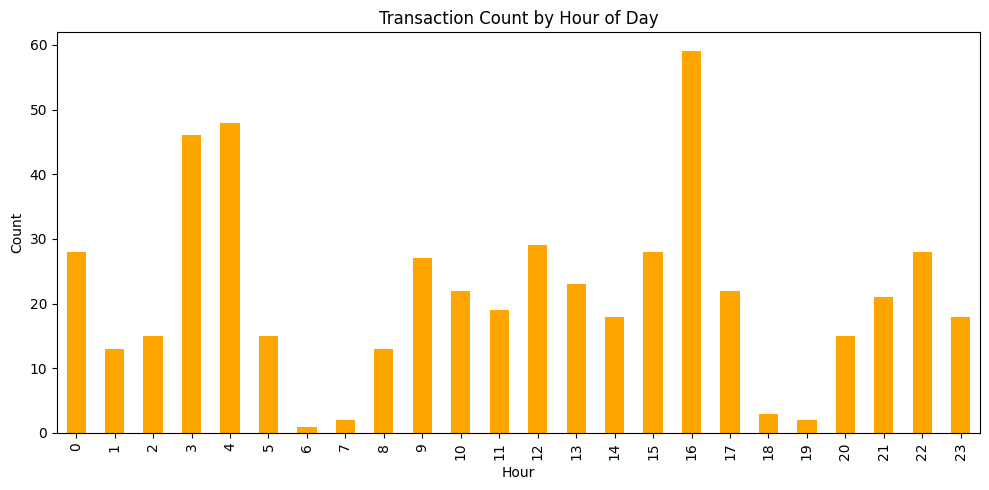

In [128]:
df['Start Hour'].value_counts().sort_index().plot(kind='bar', color='orange', figsize=(10,5))
plt.title('Transaction Count by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Average Flow Rate Distribution

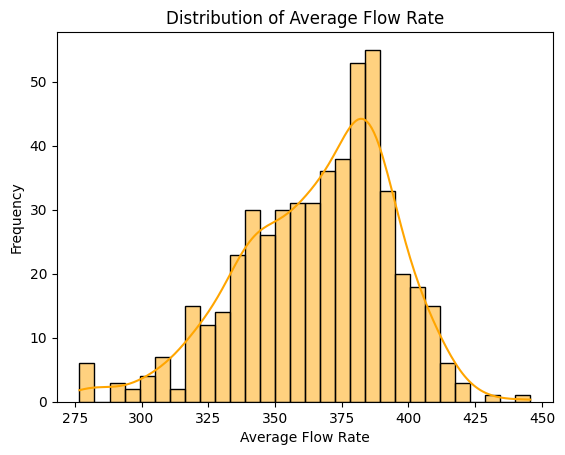

In [129]:
sns.histplot(df['Average Flow Rate'], bins=30, kde=True, color='orange')
plt.title('Distribution of Average Flow Rate')
plt.xlabel('Average Flow Rate')
plt.ylabel('Frequency')
plt.show()

### Scatter Plot: Flow Rate vs Air Temperature

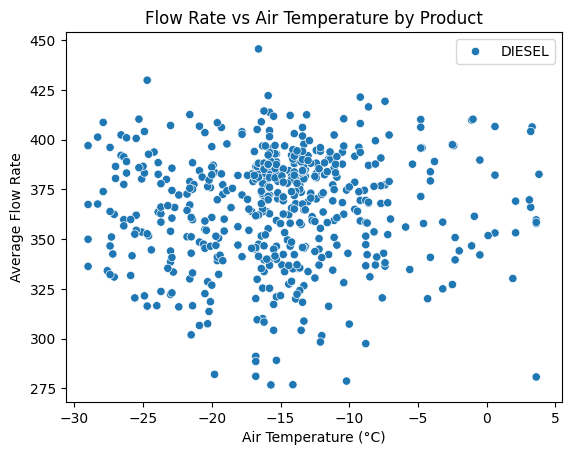

In [130]:
sns.scatterplot(data=df, x='air_temp_c', y='Average Flow Rate', hue='Product')
plt.title('Flow Rate vs Air Temperature by Product')
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Average Flow Rate')
plt.legend(loc='upper right')
plt.show()

### Downtime Analysis

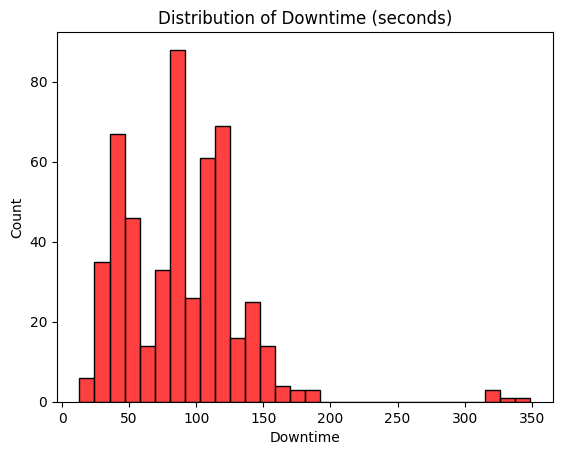

In [131]:
df['downtime_seconds'] = df['Duration in Seconds'] - df['Flow Duration Seconds']
sns.histplot(df['downtime_seconds'], bins=30, color='red')
plt.title('Distribution of Downtime (seconds)')
plt.xlabel('Downtime')
plt.show()

### Average Flow Rate by Source ID (Pump/Meter)
Shows how efficiently each pump is performing.

<ipython-input-132-81e2a0fb71a3>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Source ID', y='Average Flow Rate', palette='coolwarm')


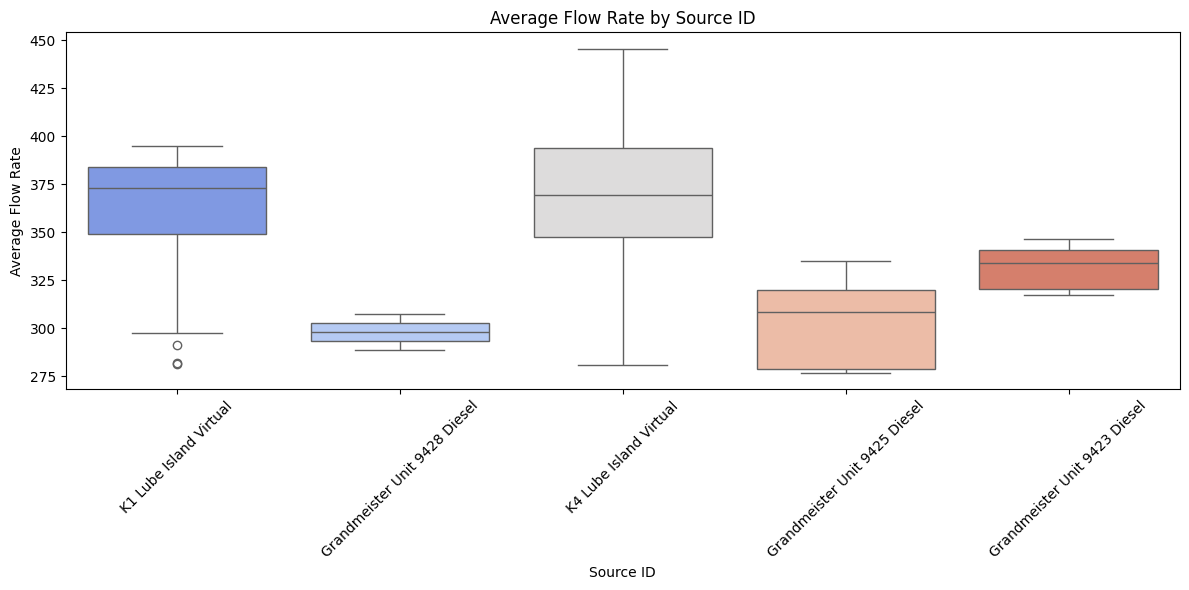

In [132]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Source ID', y='Average Flow Rate', palette='coolwarm')
plt.title('Average Flow Rate by Source ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Air Temperature vs Average Flow Rate
Check if temperature affects flow performance.

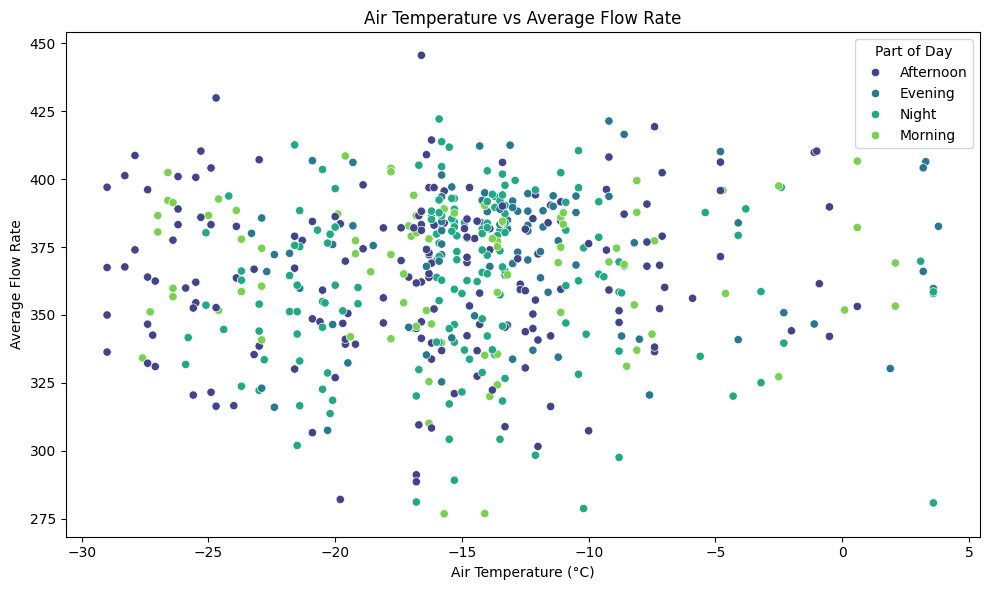

In [133]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='air_temp_c', y='Average Flow Rate', hue='Part of Day', palette='viridis')
plt.title('Air Temperature vs Average Flow Rate')
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Average Flow Rate')
plt.tight_layout()
plt.show()


### Precipitation vs Average Flow Rate
To see if rainy weather affects flow rate

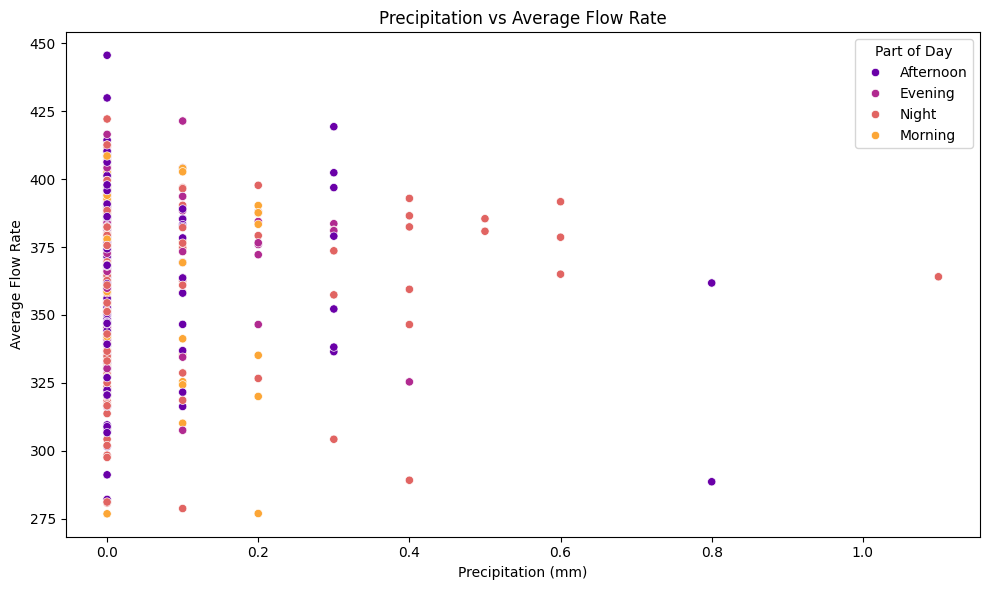

In [134]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='precipitation_mm', y='Average Flow Rate', hue='Part of Day', palette='plasma')
plt.title('Precipitation vs Average Flow Rate')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Average Flow Rate')
plt.tight_layout()
plt.show()

### Downtime Distribution

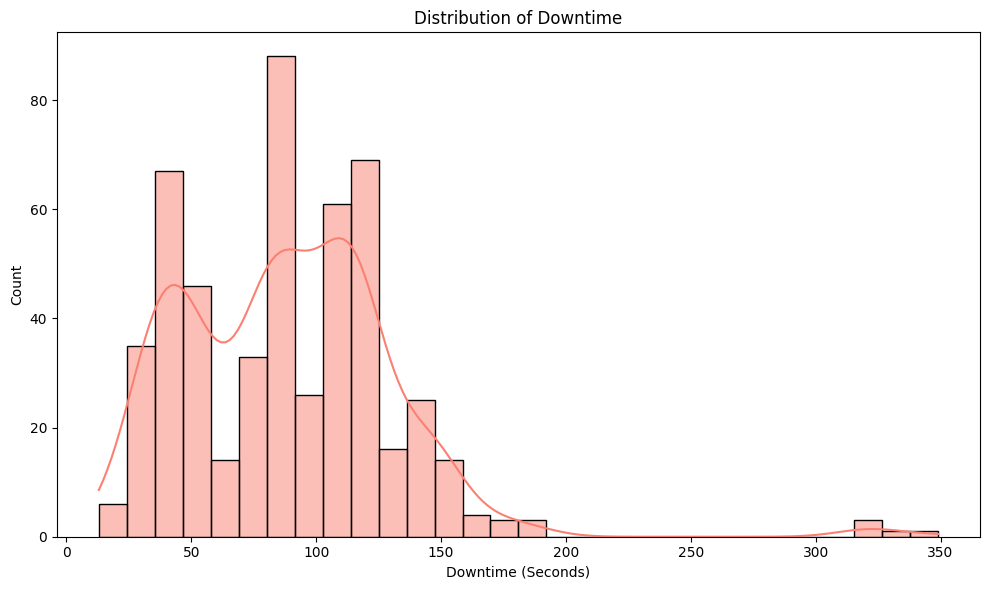

In [135]:
df['Downtime (sec)'] = df['Duration in Seconds'] - df['Flow Duration Seconds']
plt.figure(figsize=(10, 6))
sns.histplot(df['Downtime (sec)'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Downtime')
plt.xlabel('Downtime (Seconds)')
plt.tight_layout()
plt.show()


### Average Flow Rate by Part of the Day
Morning, Afternoon, Evening — performance patterns.

<ipython-input-136-2da808cc58df>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Part of Day', y='Average Flow Rate', palette='Spectral')


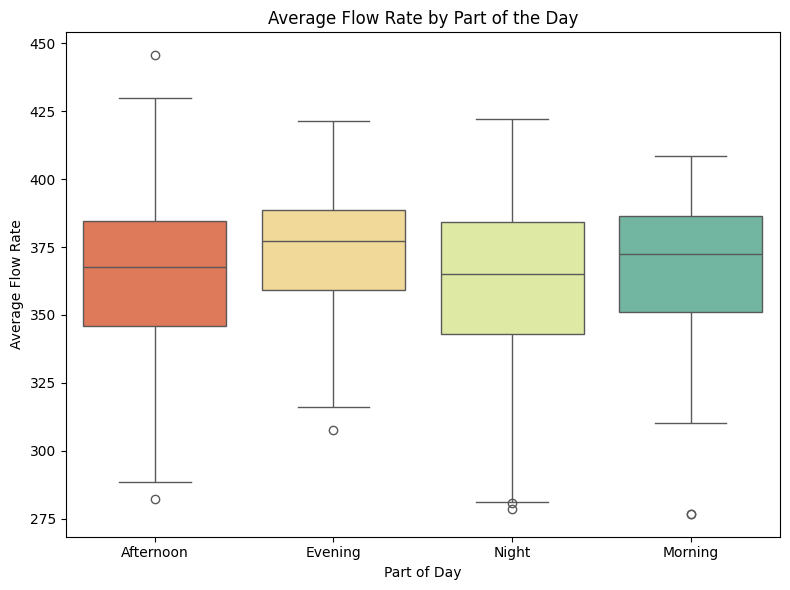

In [136]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Part of Day', y='Average Flow Rate', palette='Spectral')
plt.title('Average Flow Rate by Part of the Day')
plt.tight_layout()
plt.show()

### Average Flow Rate by Day of the Week
To analyze if certain days are slower/faster.

<ipython-input-137-84d0388bfb1b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Day of Week', y='Average Flow Rate', order=order, palette='Set2')


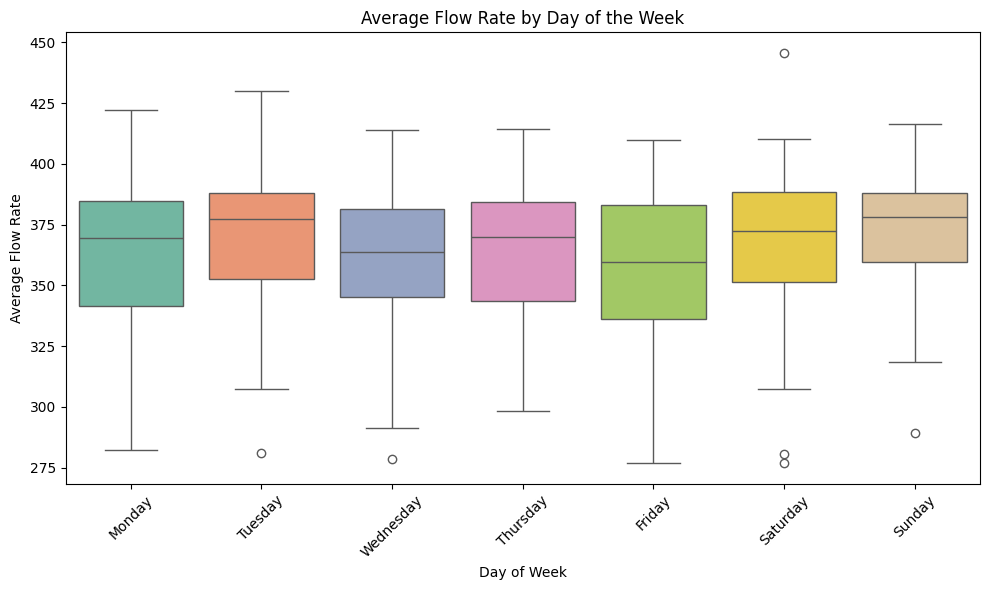

In [137]:
plt.figure(figsize=(10, 6))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df, x='Day of Week', y='Average Flow Rate', order=order, palette='Set2')
plt.title('Average Flow Rate by Day of the Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### High Downtime Flags
For flagging inefficiencies — show % of transactions with high downtime.

<ipython-input-138-7fc50d6f3aa1>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=downtime_by_day.index, y=downtime_by_day.values, palette='Reds')


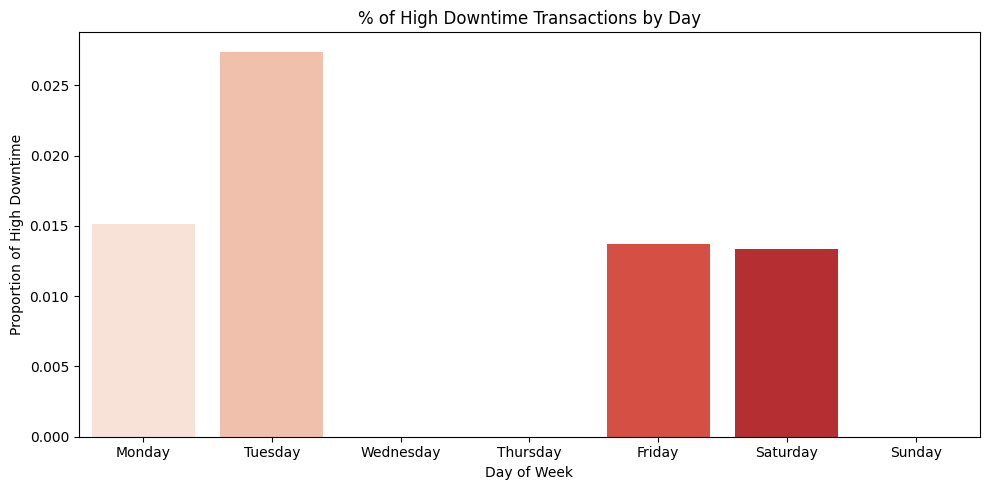

In [138]:
df['Downtime (min)'] = df['Downtime (sec)'] / 60
df['High Downtime'] = df['Downtime (min)'] > 5  # Flag if > 5 min

downtime_by_day = df.groupby('Day of Week')['High Downtime'].mean().reindex(order)

plt.figure(figsize=(10, 5))
sns.barplot(x=downtime_by_day.index, y=downtime_by_day.values, palette='Reds')
plt.title('% of High Downtime Transactions by Day')
plt.ylabel('Proportion of High Downtime')
plt.tight_layout()
plt.show()

# Feature Engineering

**Downtime:** Shows how much time was spent not dispensing fuel (can highlight delays or inefficiencies).

In [139]:
df['Downtime'] = df['Transaction Duration (Minutes)'] - (df['Flow Duration Seconds'] / 60)
df['Downtime'] = df['Downtime'].apply(lambda x: x if x > 0 else 0)

In [140]:
df.head()

,Date,End Time,Duration in Seconds,Transfer From,Source ID,Transfer To,Target ID,Product,Volume,Metered Volume,...,precipitation_mm,utc_date,Wind Direction Category,Feels Like Temp,Rain Intensity,downtime_seconds,Downtime (sec),Downtime (min),High Downtime,Downtime
0,2024-11-19 12:44:00,2024-11-19 12:50:00,333,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,TLP 2104,TLP 2104,DIESEL,1864.7,1864.7,...,0.0,2024-11-19 12:00:00,N,-12.4,No Rain,44,44,0.733333,False,0.733333
1,2024-11-19 15:24:00,2024-11-19 15:26:00,103,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,373.9,373.9,...,0.0,2024-11-19 15:00:00,N,-12.6,No Rain,30,30,0.500000,False,0.500000
2,2024-11-19 16:40:00,2024-11-19 16:58:00,1083,Mod 4 Lube Island Virtual,K4 Lube Island Virtual,Grandmeister Unit 9042 Diesel,Grandmeister Unit 9042 Diesel,DIESEL,6306.1,6306.1,...,0.0,2024-11-19 16:00:00,N,-14.3,No Rain,117,117,1.950000,False,1.950000
3,2024-11-19 16:42:00,2024-11-19 16:52:00,631,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9423 Diesel,Grandmeister Unit 9423 Diesel,DIESEL,3121.3,3121.3,...,0.0,2024-11-19 16:00:00,N,-14.3,No Rain,110,110,1.833333,False,1.833333
4,2024-11-19 16:46:00,2024-11-19 17:02:00,961,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,5108.8,5108.8,...,0.0,2024-11-19 16:00:00,N,-14.3,No Rain,164,164,2.733333,False,2.733333


**Temperature Categories**: Helps analyze impact of weather on fuel use.

In [141]:
def categorize_temp(temp):
    if temp < 0:
        return 'Freezing'
    elif temp < 10:
        return 'Cold'
    elif temp < 20:
        return 'Mild'
    else:
        return 'Warm'

df['Temp Category'] = df['air_temp_c'].apply(categorize_temp)


In [142]:
df.head()

,Date,End Time,Duration in Seconds,Transfer From,Source ID,Transfer To,Target ID,Product,Volume,Metered Volume,...,utc_date,Wind Direction Category,Feels Like Temp,Rain Intensity,downtime_seconds,Downtime (sec),Downtime (min),High Downtime,Downtime,Temp Category
0,2024-11-19 12:44:00,2024-11-19 12:50:00,333,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,TLP 2104,TLP 2104,DIESEL,1864.7,1864.7,...,2024-11-19 12:00:00,N,-12.4,No Rain,44,44,0.733333,False,0.733333,Freezing
1,2024-11-19 15:24:00,2024-11-19 15:26:00,103,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,373.9,373.9,...,2024-11-19 15:00:00,N,-12.6,No Rain,30,30,0.500000,False,0.500000,Freezing
2,2024-11-19 16:40:00,2024-11-19 16:58:00,1083,Mod 4 Lube Island Virtual,K4 Lube Island Virtual,Grandmeister Unit 9042 Diesel,Grandmeister Unit 9042 Diesel,DIESEL,6306.1,6306.1,...,2024-11-19 16:00:00,N,-14.3,No Rain,117,117,1.950000,False,1.950000,Freezing
3,2024-11-19 16:42:00,2024-11-19 16:52:00,631,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9423 Diesel,Grandmeister Unit 9423 Diesel,DIESEL,3121.3,3121.3,...,2024-11-19 16:00:00,N,-14.3,No Rain,110,110,1.833333,False,1.833333,Freezing
4,2024-11-19 16:46:00,2024-11-19 17:02:00,961,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,5108.8,5108.8,...,2024-11-19 16:00:00,N,-14.3,No Rain,164,164,2.733333,False,2.733333,Freezing


**Is High Flow:** Flag for high flow transactions (above average)

In [143]:
avg_flow = df['Average Flow Rate'].mean()
df['High Flow'] = df['Average Flow Rate'] > avg_flow


In [144]:
df.head()

,Date,End Time,Duration in Seconds,Transfer From,Source ID,Transfer To,Target ID,Product,Volume,Metered Volume,...,Wind Direction Category,Feels Like Temp,Rain Intensity,downtime_seconds,Downtime (sec),Downtime (min),High Downtime,Downtime,Temp Category,High Flow
0,2024-11-19 12:44:00,2024-11-19 12:50:00,333,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,TLP 2104,TLP 2104,DIESEL,1864.7,1864.7,...,N,-12.4,No Rain,44,44,0.733333,False,0.733333,Freezing,True
1,2024-11-19 15:24:00,2024-11-19 15:26:00,103,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,373.9,373.9,...,N,-12.6,No Rain,30,30,0.500000,False,0.500000,Freezing,False
2,2024-11-19 16:40:00,2024-11-19 16:58:00,1083,Mod 4 Lube Island Virtual,K4 Lube Island Virtual,Grandmeister Unit 9042 Diesel,Grandmeister Unit 9042 Diesel,DIESEL,6306.1,6306.1,...,N,-14.3,No Rain,117,117,1.950000,False,1.950000,Freezing,True
3,2024-11-19 16:42:00,2024-11-19 16:52:00,631,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9423 Diesel,Grandmeister Unit 9423 Diesel,DIESEL,3121.3,3121.3,...,N,-14.3,No Rain,110,110,1.833333,False,1.833333,Freezing,False
4,2024-11-19 16:46:00,2024-11-19 17:02:00,961,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,5108.8,5108.8,...,N,-14.3,No Rain,164,164,2.733333,False,2.733333,Freezing,True


**Temperature Impact Category:** Combines temp and downtime to flag operational risk

In [145]:
df['Temp Impact Risk'] = np.where((df['Feels Like Temp'] < -15) & (df['Downtime (min)'] > 1), 'High Risk', 'Low/Medium')


In [146]:
df.head()

,Date,End Time,Duration in Seconds,Transfer From,Source ID,Transfer To,Target ID,Product,Volume,Metered Volume,...,Feels Like Temp,Rain Intensity,downtime_seconds,Downtime (sec),Downtime (min),High Downtime,Downtime,Temp Category,High Flow,Temp Impact Risk
0,2024-11-19 12:44:00,2024-11-19 12:50:00,333,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,TLP 2104,TLP 2104,DIESEL,1864.7,1864.7,...,-12.4,No Rain,44,44,0.733333,False,0.733333,Freezing,True,Low/Medium
1,2024-11-19 15:24:00,2024-11-19 15:26:00,103,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,373.9,373.9,...,-12.6,No Rain,30,30,0.500000,False,0.500000,Freezing,False,Low/Medium
2,2024-11-19 16:40:00,2024-11-19 16:58:00,1083,Mod 4 Lube Island Virtual,K4 Lube Island Virtual,Grandmeister Unit 9042 Diesel,Grandmeister Unit 9042 Diesel,DIESEL,6306.1,6306.1,...,-14.3,No Rain,117,117,1.950000,False,1.950000,Freezing,True,Low/Medium
3,2024-11-19 16:42:00,2024-11-19 16:52:00,631,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9423 Diesel,Grandmeister Unit 9423 Diesel,DIESEL,3121.3,3121.3,...,-14.3,No Rain,110,110,1.833333,False,1.833333,Freezing,False,Low/Medium
4,2024-11-19 16:46:00,2024-11-19 17:02:00,961,Mod 1 Lube Island Virtual,K1 Lube Island Virtual,Grandmeister Unit 9428 Diesel,Grandmeister Unit 9428 Diesel,DIESEL,5108.8,5108.8,...,-14.3,No Rain,164,164,2.733333,False,2.733333,Freezing,True,Low/Medium


# Model Building

In [147]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


#### Define Features and Target Variable:

Define the target variable (the one we're predicting) and the features (the ones used to make the prediction).

In [148]:
# Define target and features
target = 'Average Flow Rate'
features = df.drop(columns=[target])

# Check for missing values in the dataset
print(features.isnull().sum())
print(df[target].isnull().sum())


Date                              0
End Time                          0
Duration in Seconds               0
Transfer From                     0
Source ID                         0
Transfer To                       0
Target ID                         0
Product                           0
Volume                            0
Metered Volume                    0
Temp Comp Metered Volume          0
Transaction Type                  0
Peak Flow Rate                    0
Flow Duration                     0
Start Time                        0
Flow Duration Seconds             0
Start Hour                        0
End Hour                          0
Transaction Duration (Minutes)    0
Day of Week                       0
Part of Day                       0
Flow Rate Ratio                   0
weather_id                        0
realtime_source                   0
wind_direction_deg                0
dewpoint_temp_c                   0
air_temp_c                        0
humidity_percent            

#### Train-Test Split
We will now split the data into training and testing sets (80/20 split).

In [149]:
# Split the data into features (X) and target (y)
X = features
y = df[target]

# Split into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Preprocessing Pipeline
We will handle missing values, scale numerical features, and encode categorical features in a pipeline.

In [150]:
# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Preprocessing pipeline for numeric features (impute and scale)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Fill missing values with mean
    ('scaler', StandardScaler())  # Scale features to have mean 0 and variance 1
])

# Preprocessing pipeline for categorical features (impute and encode)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical variables
])

# Combine both transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


#### Model Creation and Training
We'll create a pipeline that includes both preprocessing and model training. We'll start with Random Forest Regressor

In [151]:
# Define the model (Random Forest Regressor)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Apply preprocessing
    ('regressor', RandomForestRegressor(random_state=42))  # Random Forest Regressor
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


#### Model Evaluation
Evaluate the model's performance using common regression metrics like R-squared and Mean Absolute Error (MAE).

In [152]:
# Calculate the R-squared value and Mean Absolute Error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")


R-squared: 0.9605
Mean Absolute Error: 3.6577


#### Hyperparameter Tuning
we can improve the model by tuning hyperparameters e.g., using RandomizedSearchCV

In [153]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define hyperparameters to tune
param_dist = {
    'regressor__n_estimators': randint(50, 200),  # Random range for number of trees
    'regressor__max_depth': [None, 10, 20, 30],  # Maximum depth of trees
    'regressor__min_samples_split': randint(2, 10)  # Random range for min samples per split
}

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=20, cv=3,
                                   scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)

# Fit the random search to the training data
random_search.fit(X_train, y_train)

# Get the best parameters and model
print(f"Best Hyperparameters: {random_search.best_params_}")

# Use the best model to make predictions
best_model_random = random_search.best_estimator_
y_pred_best_random = best_model_random.predict(X_test)

# Evaluate the tuned model
r2_best_random = r2_score(y_test, y_pred_best_random)
mae_best_random = mean_absolute_error(y_test, y_pred_best_random)

print(f"R-squared (Best Model): {r2_best_random:.4f}")
print(f"Mean Absolute Error (Best Model): {mae_best_random:.4f}")


Best Hyperparameters: {'regressor__max_depth': 20, 'regressor__min_samples_split': 3, 'regressor__n_estimators': 181}
R-squared (Best Model): 0.9608
Mean Absolute Error (Best Model): 3.5266


Model Predictions: After tuning, you can use the model to make predictions on unseen test data:

In [154]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Visualize the Results: We can plot actual vs. predicted values to visually inspect how well the model performs:

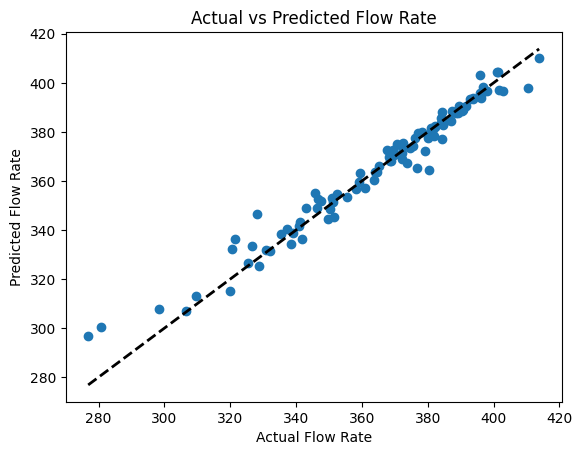

In [155]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Flow Rate')
plt.ylabel('Predicted Flow Rate')
plt.title('Actual vs Predicted Flow Rate')
plt.show()


# Model Deployment with Streamlit

Save the trained model with pickle

In [156]:
import pickle

# Save the model
with open('flow_rate_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print(" Model has been saved as 'flow_rate_model.pkl'")


 Model has been saved as 'flow_rate_model.pkl'


Creating Streamlit app

In [157]:
import streamlit as st
import pandas as pd
import pickle

# Load the trained model
with open('flow_rate_model.pkl', 'rb') as f:
    model = pickle.load(f)

st.title("Predict Average Flow Rate")
st.write("Enter details below to predict the average flow rate of the transaction:")

def user_input_features():
    # Create inputs for all the features used in training
    duration = st.number_input('Duration in Seconds', min_value=0, value=500)
    volume = st.number_input('Volume', min_value=0.0, value=1000.0)
    is_weekend = st.selectbox('Is Weekend?', ['Yes', 'No'])
    temp_category = st.selectbox('Temp Category', ['Cold', 'Hot', 'Freezing', 'Mild'])
    hour = st.slider('Hour', 0, 23, 12)
    high_flow = st.selectbox('High Flow?', ['Yes', 'No'])
    temp_risk = st.selectbox('Temp Impact Risk', ['Low/Medium', 'High'])

    data = {
        'Duration in Seconds': duration,
        'Volume': volume,
        'Is Weekend': 1 if is_weekend == 'Yes' else 0,
        'Temp Category': temp_category,
        'Hour': hour,
        'High Flow': 1 if high_flow == 'Yes' else 0,
        'Temp Impact Risk': temp_risk
    }

    return pd.DataFrame([data])

# Get user input
input_df = user_input_features()

# Make prediction
if st.button('Predict Average Flow Rate'):
    prediction = model.predict(input_df)
    st.subheader("Predicted Average Flow Rate:")
    st.success(f"{round(prediction[0], 2)} units")


2025-04-13 02:56:04.780 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 02:56:04.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 02:56:04.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 02:56:04.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 02:56:04.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 02:56:04.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 02:56:04.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 02:56:04.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar